This file should cover all steps to generate a graph from Leons predictions

In [31]:
from glob import glob
import nibabel as nib
from skimage.morphology import skeletonize
import sknw
from pathlib import Path
import numpy as np
from skimage.measure import label
import networkx as nx
import json

# remove when not needed anymore
from data.visualizations import visualize_3d_matrices
import matplotlib.pyplot as plt

import pprint

Input Data: prediction

1. load prediction
2. divide prediction in coronary artery 1 and 2. We get pred1 and pred2. pred1 only has 1 coronary artery, and pred2 the other.

next steps for both pred 1 and pred 2
3. get skeleton
4. get sknw graph
5. get edge points + calculate the root point(s) (root 1 and root 2 respectively)
6. set the root points in the graph

7. Combine both graphs into one
8. For each node: convert the positions to RAS coordinate system
9. Calculate the lenghts of the edges. Make sure to follow the artery path.
10. save to disk with correct file name

11. test and debug using profs eval script.

12. Run on Leons predictions folder

In [6]:
# step 1: load the mask

data_folder = Path("graph_generation_test")
label_fp = data_folder / "00328c.label.nii.gz"
mask = nib.load(label_fp)
mask_array = mask.get_fdata()

# we will not load the graph for now to make sure we're not cheating

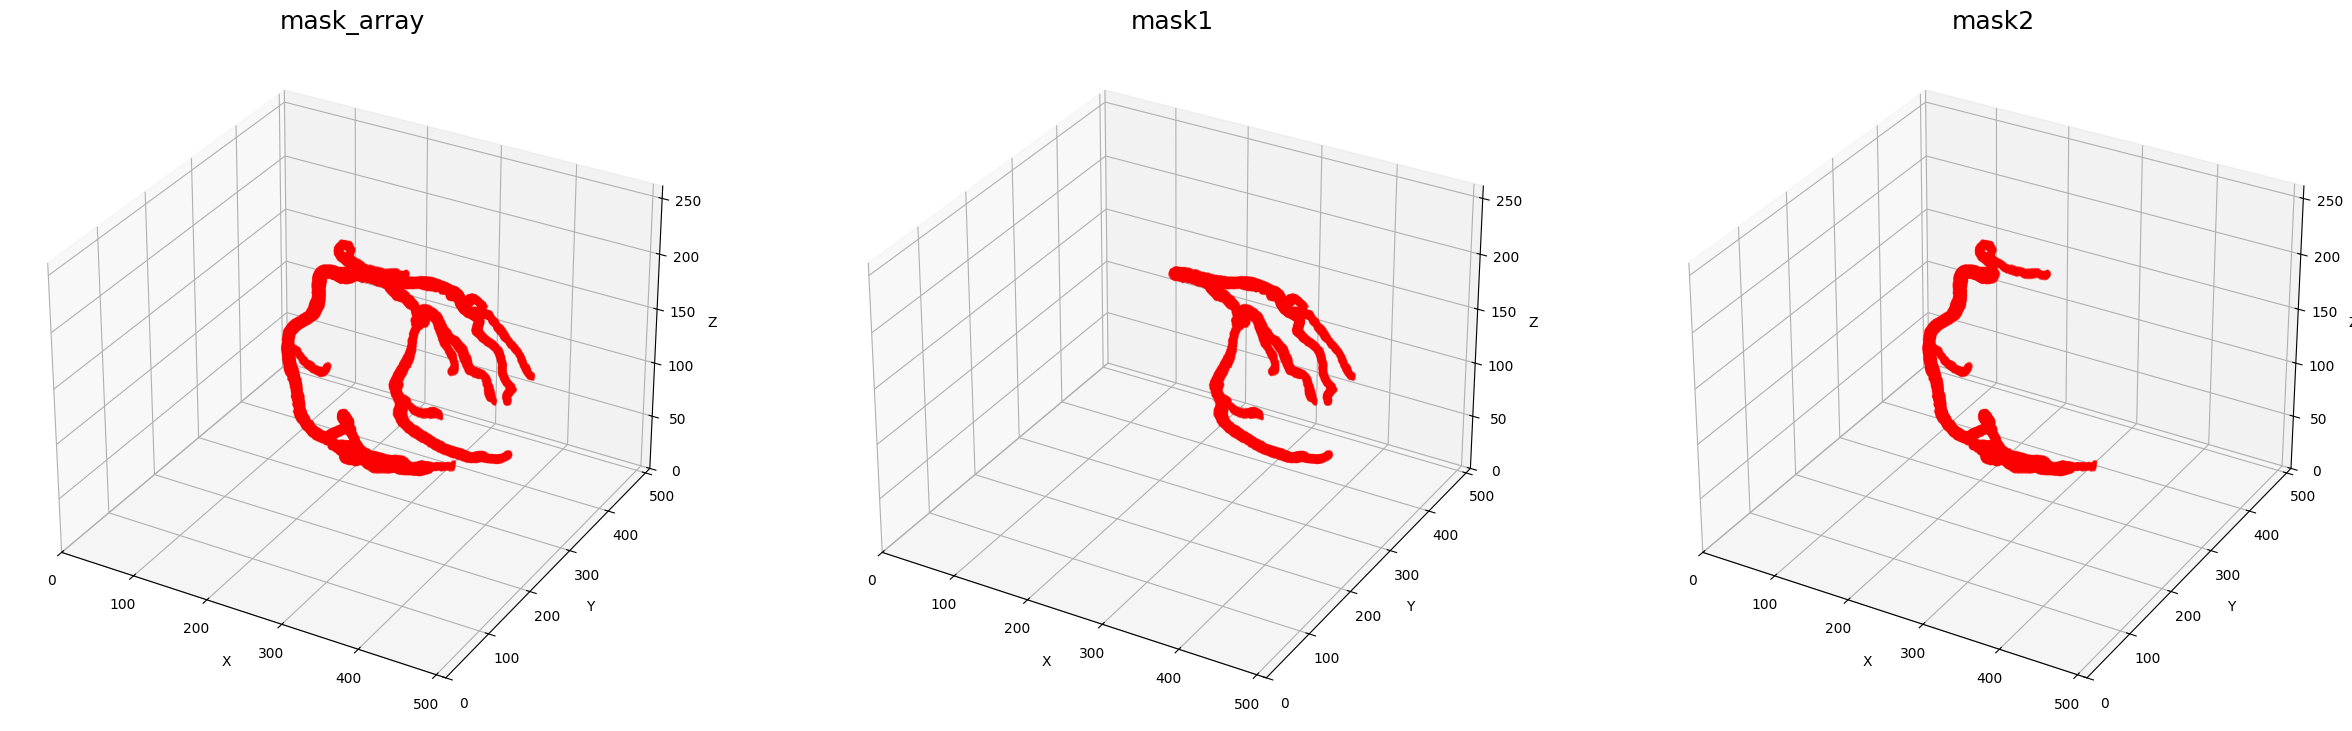

In [7]:
# step 2: divide the mask into mask1 and mask 2 with coronary artery 1 and coronary artery 2
def divide_mask(mask_array):
    # Label connected components
    labeled_array, _ = label(mask_array, return_num=True)

    # Use a histogram to efficiently calculate the sizes of each labeled component
    component_sizes = np.bincount(labeled_array.ravel())

    # Exclude the background component (label 0)
    component_sizes[0] = 0

    # Get the two largest component labels
    largest_labels = np.argsort(component_sizes)
    largest_labels = largest_labels[-2:]

    # this should include the left and right coronary artery.
    # let's create a mask with both and compare it with the original mask

    # Create a mask for each component
    largest_mask_0 = np.isin(labeled_array, largest_labels[0])
    largest_mask_1 = np.isin(labeled_array, largest_labels[1])

    return largest_mask_0, largest_mask_1

mask1, mask2 = divide_mask(mask_array)

visualize_3d_matrices([mask_array, mask1, mask2], ["mask_array", "mask1", "mask2"])


In [8]:
# step 3: get the skeleton of the mask

def get_skeleton(mask):
    skeleton = skeletonize(mask)
    return skeleton

skeleton1 = get_skeleton(mask1)
skeleton2 = get_skeleton(mask2)

In [56]:
def plot_networkx_graph(graph_data, title):
    plt.figure()
    ax = plt.subplot(111, projection='3d')

    for node_id in graph_data.nodes:
        pos = graph_data.nodes[node_id]['pts']
        print(pos)

        # if it has attribute "is_root" and it's True, color it green
        if graph_data.nodes[node_id].get("is_root", False):
            ax.scatter(pos[0], pos[1], pos[2], s=100, c='g')
        else:
            ax.scatter(pos[0], pos[1], pos[2], c='r')
    
    for (s, e) in graph_data.edges():
        ps = graph_data[s][e]['pts']
        ax.plot(ps[:, 0], ps[:, 1], ps[:, 2], c='b')

    plt.title(title)
    plt.show()

Graph with 26 nodes and 27 edges
Graph with 39 nodes and 49 edges


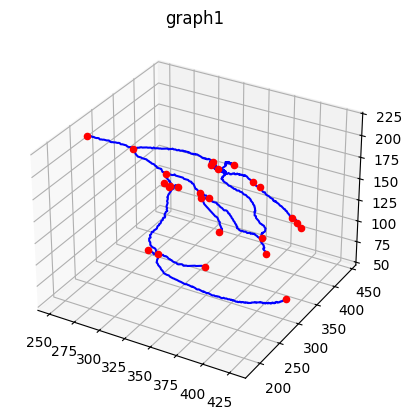

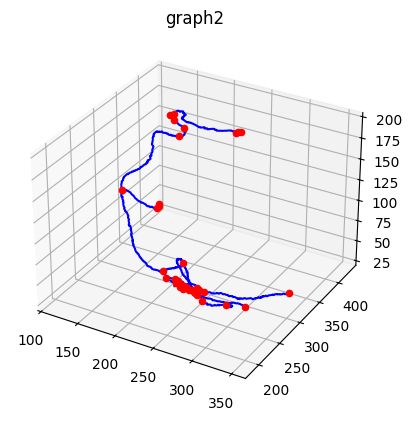

In [10]:
# step 4: get the sknw graph of the skeleton

def get_graph(skeleton):
    graph = sknw.build_sknw(skeleton)
    return graph

graph1 = get_graph(skeleton1)
graph2 = get_graph(skeleton2)

print(graph1)
print(graph2)

plot_networkx_graph(graph1, "graph1")
plot_networkx_graph(graph2, "graph2")

In [54]:
# step 5: get edge points + calculate the root point(s) (root 1 and root 2 respectively)

# graph_data1 = nx.node_link_data(graph1)
# graph_data2 = nx.node_link_data(graph2)

def find_root_cube_northern_weighted(graph_data, mask_array, cube_size=50):
    def get_node_coords(node_id):
        """Extracts node coordinates from graph_data."""
        return graph_data.nodes[node_id]["pts"][0]

    def get_cube_sum_and_average(coords, cube_size, edt):
        """Calculates the sum and average of edt values within a cubic volume centered at coords."""
        x, y, z = coords
        half_size = cube_size // 2

        # Define the bounds, ensuring they stay within the edt boundaries
        x_min = max(0, x - half_size)
        x_max = min(edt.shape[0], x + half_size + 1)
        y_min = max(0, y - half_size)
        y_max = min(edt.shape[1], y + half_size + 1)
        z_min = max(0, z - half_size)
        z_max = min(edt.shape[2], z + half_size + 1)

        # Extract the cube and compute sum and average
        cube = edt[x_min:x_max, y_min:y_max, z_min:z_max]
        cube_sum = np.sum(cube)
        cube_avg = cube_sum / cube.size

        return cube_sum, cube_avg

    terminal_nodes = {
        node for node in graph_data.nodes if graph_data.degree(node) == 1
    }

    best_node = None
    max_weighted_score = 0

    for node in terminal_nodes:
        node_coords = get_node_coords(node)
        _, cube_avg = get_cube_sum_and_average(node_coords, cube_size, mask_array)
        z_value = node_coords[2]  # Extract the z coordinate

        # Compute weighted score (50% cube sum, 50% z coordinate)
        weighted_score = 0.5 * cube_avg + 0.5 * z_value

        if weighted_score > max_weighted_score:
            max_weighted_score = weighted_score
            best_node = node

    return best_node

found_root_1_id = find_root_cube_northern_weighted(graph1, mask_array)
found_root_2_id = find_root_cube_northern_weighted(graph2, mask_array)

print(found_root_1_id)
print(found_root_2_id)

'''
def find_roots(file_path="/group/gecko/oberbabo/results/output_model_ensemble/*.labels.nii.gz"):
    for seg in glob(file_path):
        mask_matrice = nib.load(seg).get_fdata()
        skeleton = skeletonize(mask_matrice)
        snkw_graph = sknw.build_sknw(skeleton, multi=False, iso=False)
        largest_ccs = [
            (c, len(c))
            for c in sorted(nx.connected_components(snkw_graph), key=len, reverse=True)
        ]
        # Extract the two largest connected components
        largest_cc1 = largest_ccs[0][0]
        largest_cc2 = largest_ccs[1][0]
        # Create subgraphs for the two largest components
        subgraph1 = snkw_graph.subgraph(largest_cc1)
        subgraph2 = snkw_graph.subgraph(largest_cc2)
        root1 = find_root_cube_northern_weighted(subgraph1, mask_matrice)
        root2 = find_root_cube_northern_weighted(subgraph2, mask_matrice)
        
        for node in snkw_graph.nodes:
            if node not in (root1, root2):
                snkw_graph.nodes[node]['is_root'] = False
            else:
                snkw_graph.nodes[node]['is_root'] = True
'''


0
12


'\ndef find_roots(file_path="/group/gecko/oberbabo/results/output_model_ensemble/*.labels.nii.gz"):\n    for seg in glob(file_path):\n        mask_matrice = nib.load(seg).get_fdata()\n        skeleton = skeletonize(mask_matrice)\n        snkw_graph = sknw.build_sknw(skeleton, multi=False, iso=False)\n        largest_ccs = [\n            (c, len(c))\n            for c in sorted(nx.connected_components(snkw_graph), key=len, reverse=True)\n        ]\n        # Extract the two largest connected components\n        largest_cc1 = largest_ccs[0][0]\n        largest_cc2 = largest_ccs[1][0]\n        # Create subgraphs for the two largest components\n        subgraph1 = snkw_graph.subgraph(largest_cc1)\n        subgraph2 = snkw_graph.subgraph(largest_cc2)\n        root1 = find_root_cube_northern_weighted(subgraph1, mask_matrice)\n        root2 = find_root_cube_northern_weighted(subgraph2, mask_matrice)\n        \n        for node in snkw_graph.nodes:\n            if node not in (root1, root2):\n

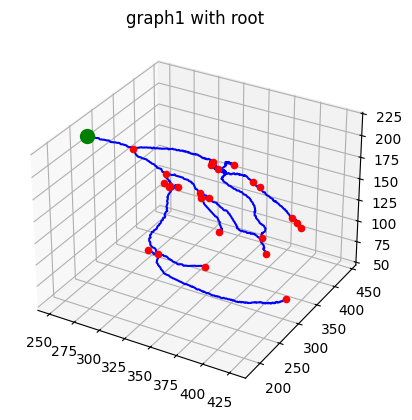

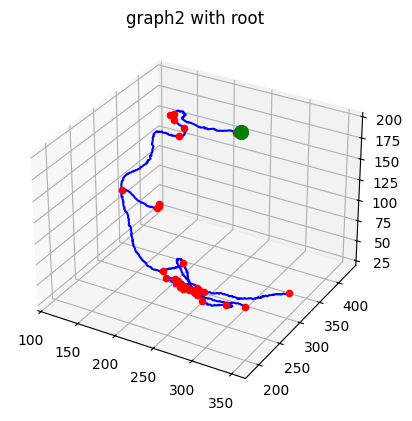

In [12]:
# step 6 insert the root points into the graph

def insert_root_point(graph, root_id):
    for node in graph.nodes:
        if node != root_id:
            graph.nodes[node]["is_root"] = False
        else:
            graph.nodes[root_id]["is_root"] = True

    return graph

graph1 = insert_root_point(graph1, found_root_1_id)
graph2 = insert_root_point(graph2, found_root_2_id)

# let's visualize the graphs with the root points
plot_networkx_graph(graph1, "graph1 with root")
plot_networkx_graph(graph2, "graph2 with root")

Graph with 26 nodes and 27 edges
Graph with 39 nodes and 49 edges
Graph with 65 nodes and 76 edges


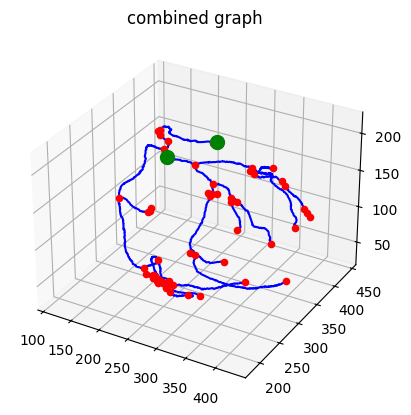

In [21]:
# step 7 combine both graphs into one graph

def combine_graphs(graph1, graph2):
    # copy the graphs to avoid modifying the original graphs
    graph1 = graph1.copy()
    graph2 = graph2.copy()

    # get the max node id from graph1
    max_node_id = max(graph1.nodes)

    # create a mapping to relabel nodes in graph2
    mapping = {node: node + max_node_id + 1 for node in graph2.nodes}

    # relabel the nodes in graph2
    graph2 = nx.relabel_nodes(graph2, mapping)

    combined_graph = nx.compose(graph1, graph2)
    return combined_graph

combined_graph = combine_graphs(graph1, graph2)

print(graph1)
print(graph2)
print(combined_graph)

plot_networkx_graph(combined_graph, "combined graph")

[  -4.56738281  156.93261719 -178.04998779]
[  -4.56738281  156.93261719 -178.04998779]
[ -17.30175781  160.43457031 -181.04998779]
[ -17.30175781  160.43457031 -181.04998779]
[ -28.12597656  158.52441406 -188.54998779]
[ -28.12597656  158.52441406 -188.54998779]
[ -30.35449219  151.83886719 -188.54998779]
[ -30.35449219  151.83886719 -188.54998779]
[ -32.26464844  134.96582031 -214.54998779]
[ -32.26464844  134.96582031 -214.54998779]
[ -32.26464844  151.83886719 -189.04998779]
[ -32.26464844  151.83886719 -189.04998779]
[ -32.58300781  149.92871094 -188.54998779]
[ -32.58300781  149.92871094 -188.54998779]
[ -33.21972656  180.49121094 -194.04998779]
[ -33.21972656  180.49121094 -194.04998779]
[ -33.21972656  182.40136719 -193.54998779]
[ -33.21972656  182.40136719 -193.54998779]
[ -33.21972656  199.59277344 -205.54998779]
[ -33.21972656  199.59277344 -205.54998779]
[ -34.17480469  152.79394531 -189.04998779]
[ -34.17480469  152.79394531 -189.04998779]
[ -35.12988281  134.96582031 -21

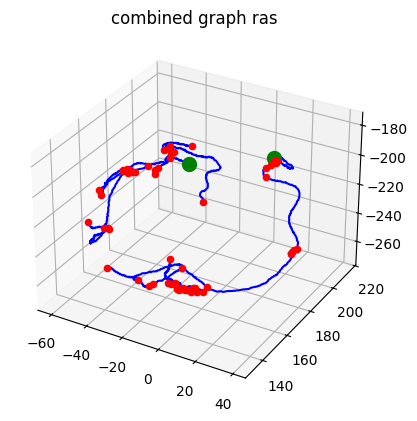

In [57]:
# step 8: convert the positions to RAS coordinate system

def convert_points_to_ras(point, affine):
    point = np.array(point)
    point = np.append(point, 1)
    
    point = affine @ point

    return point[:3]

def transform_graph_coordinates(graph, affine, position_key='pts'):
    """
    Transforms the coordinates of a NetworkX graph to a new coordinate system.

    Parameters:
    - graph: A NetworkX graph with node positions stored under a specific attribute.
    - affine: A 4x4 numpy array representing the affine transformation matrix.
    - position_key: The key in the node attribute dictionary where positions are stored.

    Returns:
    - transformed_graph: A new graph with transformed node positions.
    """
    transformed_graph = graph.copy()
    for node in transformed_graph.nodes:
        data = transformed_graph.nodes[node]
        pos = data[position_key][0]

        ras_pos = convert_points_to_ras(pos, affine)
        print(ras_pos)
        data[position_key] = ras_pos
        print(data[position_key])

    # Transform edge positions, if applicable
    for u, v, edge_data in transformed_graph.edges(data=True):
        if position_key in edge_data:
            edge_pos = edge_data[position_key]
            transformed_edge_pos = [
                convert_points_to_ras(pos, affine) for pos in edge_pos
            ]
            edge_data[position_key] = np.array(transformed_edge_pos)
        
    return transformed_graph

combined_graph_ras = transform_graph_coordinates(combined_graph, mask.affine)

plot_networkx_graph(combined_graph_ras, "combined graph ras")

In [58]:
# calculate the lengths of the edges

def calculate_edge_lengths(graph):
    for u, v, edge_data in graph.edges(data=True):
        # calculate the length of the edge, following the path of the edge
        length = 0

        for i in range(len(edge_data["pts"]) - 1):
            length += np.linalg.norm(edge_data["pts"][i + 1] - edge_data["pts"][i])
        
        edge_data["length"] = length
    return graph

combine_graph_final = calculate_edge_lengths(combined_graph_ras.copy())

In [59]:
class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)

In [60]:
# let's fix that the position is "pts" and not "pos"

def fix_position_key(graph):
    for node, data in graph.nodes(data=True):
        if "pts" in data:
            data["pos"] = data.pop("pts")  # Move 'pos' to 'pts'
    
    for u, v, data in graph.edges(data=True):
        if "pts" in data:
            data["pos"] = data.pop("pts")
    return graph

combine_graph_final = fix_position_key(combine_graph_final)
print(json.dumps(nx.node_link_data(combine_graph_final, edges="edges"), cls=NumpyEncoder))

{"directed": false, "multigraph": false, "graph": {}, "nodes": [{"o": [251, 260, 215], "is_root": true, "pos": [-4.5673828125, 156.9326171875, -178.04998779296875], "id": 0}, {"o": [291, 271, 209], "is_root": false, "pos": [-17.3017578125, 160.4345703125, -181.04998779296875], "id": 1}, {"o": [325, 265, 194], "is_root": false, "pos": [-28.1259765625, 158.5244140625, -188.54998779296875], "id": 2}, {"o": [332, 244, 194], "is_root": false, "pos": [-30.3544921875, 151.8388671875, -188.54998779296875], "id": 3}, {"o": [338, 191, 142], "is_root": false, "pos": [-32.2646484375, 134.9658203125, -214.54998779296875], "id": 4}, {"o": [339, 244, 193], "is_root": false, "pos": [-32.2646484375, 151.8388671875, -189.04998779296875], "id": 5}, {"o": [340, 239, 194], "is_root": false, "pos": [-32.5830078125, 149.9287109375, -188.54998779296875], "id": 6}, {"o": [344, 334, 184], "is_root": false, "pos": [-33.2197265625, 180.4912109375, -194.04998779296875], "id": 7}, {"o": [341, 340, 184], "is_root": 

In [63]:
# 10 save to disk with the correct file name

def save_graph(graph, file_path):
    # get json from graph
    graph_data = nx.node_link_data(graph, edges="edges")

    # save json to file
    with open(file_path, "w") as f:
        json.dump(graph_data, f, cls=NumpyEncoder)
    
    return graph_data

graph_data = save_graph(combine_graph_final, "combined_graph.json")
pprint.pprint(graph_data["edges"][0])
pprint.pprint(graph_data["nodes"][0])

{'length': 16.255180897084365,
 'pos': array([[  -4.56738281,  156.93261719, -178.04998779],
       [  -4.88574219,  157.25097656, -178.04998779],
       [  -5.20410156,  157.25097656, -178.04998779],
       [  -5.52246094,  157.25097656, -178.04998779],
       [  -5.84082031,  157.56933594, -178.54998779],
       [  -6.15917969,  157.88769531, -178.54998779],
       [  -6.47753906,  157.56933594, -178.54998779],
       [  -6.79589844,  157.56933594, -178.54998779],
       [  -7.11425781,  157.56933594, -178.54998779],
       [  -7.43261719,  157.88769531, -178.54998779],
       [  -7.75097656,  157.88769531, -178.54998779],
       [  -8.06933594,  157.88769531, -179.04998779],
       [  -8.38769531,  158.20605469, -179.04998779],
       [  -8.70605469,  158.20605469, -179.04998779],
       [  -9.02441406,  158.52441406, -179.04998779],
       [  -9.34277344,  158.52441406, -179.04998779],
       [  -9.66113281,  158.52441406, -179.04998779],
       [  -9.97949219,  158.52441406, -179.

In [62]:
def dummy_save(gt_folder, pred_folder, graph_data):
    amt_saves = 10

    dummy_idxs = [] 

    for i in range(amt_saves):
        dummy_idxs.append("abcd" + str(i)) 

    for dummy_idx in dummy_idxs:
        with open(f"{gt_folder}/{dummy_idx}.graph.json", "w") as f:
            json.dump(graph_data, f, cls=NumpyEncoder)

        with open(f"{pred_folder}/{dummy_idx}.graph.json", "w") as f:
            json.dump(graph_data, f, cls=NumpyEncoder)

label_folder = "graph_label"
pred_folder = "graph_test"

dummy_save(label_folder, pred_folder, graph_data)